<a href="https://colab.research.google.com/github/Jugyeo/AP155_TX1_1sAY2627/blob/main/Domingo_Judiele/7RootFinding_Domingo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_:
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Domingo, Judiele Fatima P.
- _Student No._: 2023-05167
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 |
| Code appropriateness  | XX | 20 |
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure
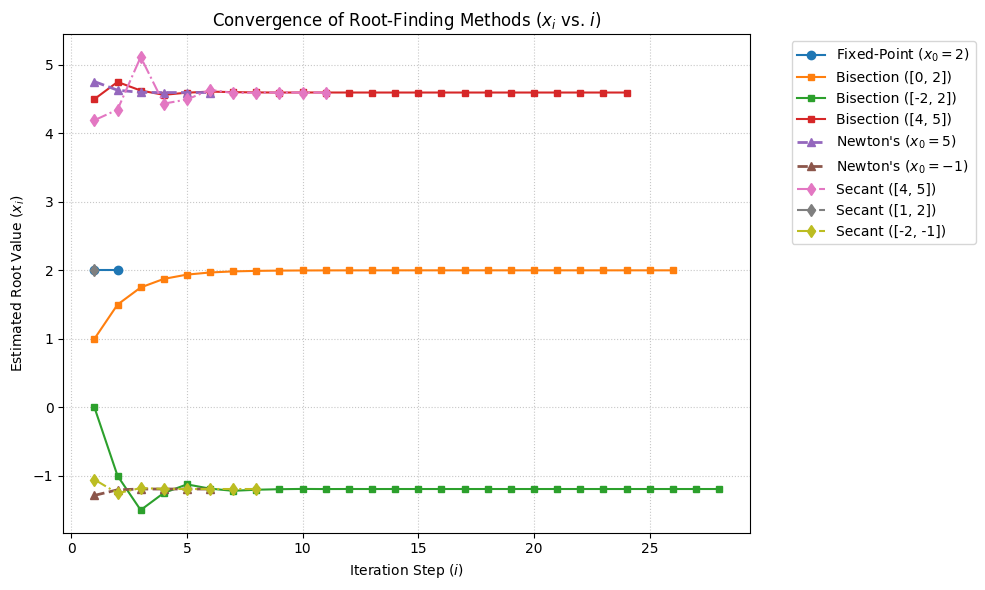

**Figure 1:** Convergence of the fixed-point, bisection, Newton's, and secant methods.

Fig.1 plots the estimated root value $(x_i)$ over the ith iteration step. All four methods converge to at least one root of the given f(x) approximately x = -1.19, x = 2.00, and x = 4.60. The Curves are labeled according to the method used as well as the initial guess used.

### Report discussion

Figure 1 shows the convergence behavior of the four methods. The fixed method took 2 iterations to find the root 2. It however did not find the other roots due to overflow. The fixed point method is more suited for functions with known or easy to estimate roots as well as functions with fewer operations to avoid overflow.

The bisection method was able to find all roots but converged more slowly, it also took the most iterations among all four methods. The bisection method is the most reliable however it takes more processing time due to continuous halving of the interval. It is best suited for complex functions with multiple operations or with functions with unkown roots.

The Newton's method found 2 of the roots, x=2 could not be found due to the structure of f'(x). It converged the fastest among all four methods taking the least number of iterations. However, it requires computing the derivative which may be hard for some functions. It also may diverge or converge to an unintended root if the initial guess is poor. The Newton's method is most suited for smooth and differentiable variables or for functions with known derivatives.

The secant method found all 3 roots, and converges almost as fast as Newton's method. The method does not require another function g(x) or f'(x) however, intial guesses need to be near the root. Therefore, the secant method ids best used for unkown derivatives which have roots that are easy to estimate.



### Other comments
- N/A


---
## Section 2: Code

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

getting g(x) for fixed_point method
$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8 = 0
$$
$$g(x) = x = \frac{1}{8}(x^5 - 4x^4 + 4x^3 - x^2 e^x + 2x^2 + 4xe^x - 4e^x +8)$$
factoring
$$
-x^3(x-2)^2 +e^x(x-2)^2-2(x-2)^2 = 0
$$
$$(x-2)^2(-x^3+e^x-2)=0$$
$$-x^3+e^x-2=0$$
$$(e^x-2)^\frac{1}{3}=x = g(x)$$

roots should contain x=2 and 2 roots from exponential part
derivative
$$ f'(x) = -5x^4 +16x^3 -+ 2xe^x +x^2e^x - 4x -4e^x -4xe^x + 8 +4e^x$$

In [73]:
"""
fixed point method:
1. find g(x) such that g(x)=x is equivalent to f(x)=0
2. plug in x_n+1 = g(x_n) and iterate
3. stop when |x_n+1-x_n|<tol
4. stop trial after max iterations without converging

bisection method:
1. find an interval to evaluate f(x)
2. get midpoint and eval f at midpoint
3. decide if x is in lower or upper half of the interval
4. stop if f at midpoint is lower than tol
5. stop after max iterations without converging

newton's method:
1. find derivative of f(x)
2. plug in x_n+1 = x_n - f(x_n)/f'(x_n) and iterate
3. stop when |x_n+1-x_n|<tol
4. stop after max iterations without converging

secant method:
1. choose 2 initial guesses near roots
2.apply secant formula
3. stop when xdiff/x2 less than tol
4. stop after max iterations without converging
"""
#parameters
x = np.linspace(-2, -5, 5000)
def f(x): #original function
  return -x**5 + 4*x**4 - 4*x**3 + x**2*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8
def g(x): #equivalent function for fixed-point
  return 1/8*(x**5 - 4*x**4 + 4*x**3 - x**2*np.exp(x) + 2*x**2 + 4*x*np.exp(x) - 4*np.exp(x) + 8)
def f_prime(x): #derivative of f(x)
  return -5*x**4 + 16*x**3 - 12*x**2 + 2*x*np.exp(x) + x**2*np.exp(x) - 4*x - 4*np.exp(x) - 4*x*np.exp(x) + 8 + 4*np.exp(x)



In [74]:
#fixed point function stops iterating after 100
def fixed_point(g, x_old, tol=1e-8, max_iter=200):#use initial guess near root
  history = [x_old] #for tracking
  for k in range(1,max_iter):
    x_new=g(x_old) #plug in x_n+1 = g(x_n)
    history.append(x_new) #add to history
    x_diff = x_new - x_old
    #stops if abs val is less diff is less than tolerance
    if abs(x_diff)<tol:
      break
    x_old = x_new
  else:
    x_new = None
  return x_new, history

#bisection method function
def bisection(f,x0,x1, tol=1e-8, max_iter=200): #x0 and x1 are upper and lower boundaries
  history = [] #for tracking
  f0 = f(x0)
  for k in range(1,max_iter):
    x2 = (x0+x1)/2 #calculates midpint of given integral
    f2 = f(x2)
    history.append(x2) #adds to history
    if f0*f2 < 0: #checks where x is located
      x1 = x2
    else:
      x0,f0 = x2,f2

    x2_new = (x0+x1)/2 #gets new mid point
    x_diff = abs(x2_new - x2)

    if abs(x_diff/x2_new) < tol: #stops if abs is below tolerance
      break
  else:
    x2_new = None
  return x2_new, history

#Newton's method
def newton(f, f_prime, x_old, tol=1e-8, max_iter=200):
  history = [] #for tracking
  for k in range(1,max_iter):
    x_new = x_old - f(x_old)/f_prime(x_old) #newton's formula
    history.append(x_new) #adds to history
    x_diff = abs(x_new - x_old)
    if abs(x_diff/x_new) < tol:
      break
    x_old = x_new
  else:
    x_new = None
  return x_new, history

#secant method
def secant(f, x0, x1, tol=1e-8, max_iter=200): #x0 and x1 are initial guesses for both roots; choose values near roots
  f0 = f(x0)
  history=[] #for tracking
  for k in range(1,max_iter):
    f1 = f(x1)
    ratio = (x1-x0)/(f1-f0)
    x2 = x1 - f1*ratio #secant formula
    history.append(x2)
    x_diff = abs(x2-x1)
    x0,x1 = x1,x2
    f0 = f1

    if abs(x_diff/x2) < tol:
      break
  else:
    x2 = None
  return x2, history

**GETTING ROOTS USING ALL 4 METHODS**

In [75]:
fixed_root, fixed_history = fixed_point(g, 2)
fixed_root

np.float64(2.0)

In [76]:
bisection_root1, bisection_history1 = bisection(f,0,2)
bisection_root1

1.9999999552965164

In [77]:
bisection_root2, bisection_history2 = bisection(f,-2,2)
bisection_root2

-1.1926857605576515

In [78]:
bisection_root3, bisection_history3 = bisection(f,4,5)
bisection_root3

4.595863550901413

In [79]:
newton_root1, newton_history1 = newton(f,f_prime,5)
newton_root1

np.float64(4.595863564922452)

In [80]:
newton_root2, newton_history2 = newton(f,f_prime,-1)
newton_root2

np.float64(-1.1926857650225988)

In [81]:
secant_root1, secant_history1 = secant(f,4,5)
secant_root1

np.float64(4.5958635649223725)

In [82]:
secant_root2, secant_history2 = secant(f,1,2)
secant_root2

np.float64(2.0)

In [83]:
secant_root3, secant_history3 = secant(f,-2,-1)
secant_root3

np.float64(-1.1926857650225988)

**PLOTTING**

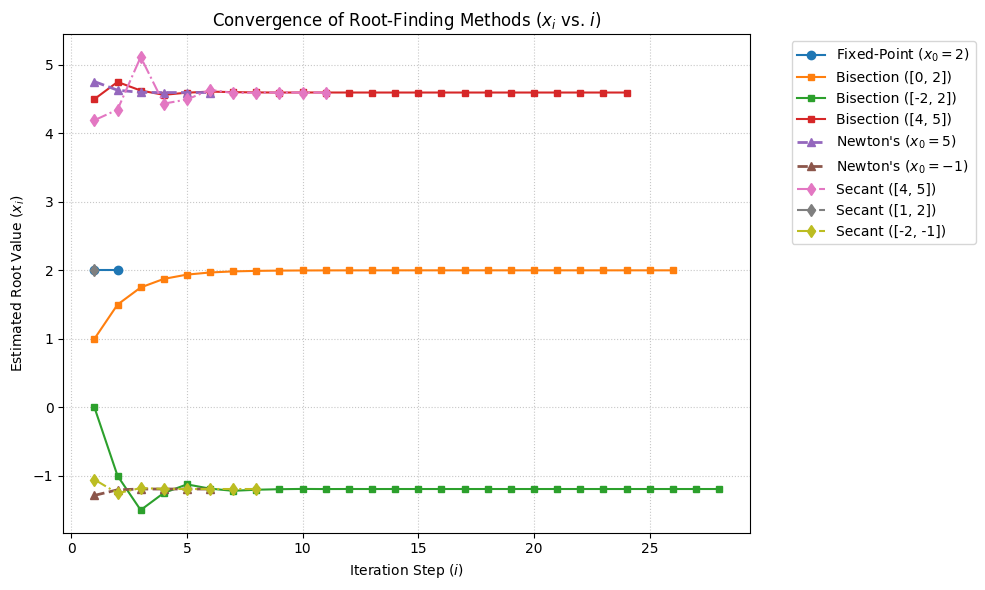

In [90]:
plt.figure(figsize=(10, 6))

# Plot each hsitory vs i for each method
plt.plot(
    range(1, len(fixed_history) + 1),
    fixed_history,
    "o-",
    label="Fixed-Point ($x_0=2$)",

)

plt.plot(
    range(1, len(bisection_history1) + 1),
    bisection_history1,
    "s-",
    label="Bisection ([0, 2])",
    markersize=5,
)
plt.plot(
    range(1, len(bisection_history2) + 1),
    bisection_history2,
    "s-",
    label="Bisection ([-2, 2])",
    markersize=5,
)
plt.plot(
    range(1, len(bisection_history3) + 1),
    bisection_history3,
    "s-",
    label="Bisection ([4, 5])",
    markersize=5,
)

plt.plot(
    range(1, len(newton_history1) + 1),
    newton_history1,
    "^--",
    label="Newton's ($x_0=5$)",
    linewidth=2,
)
plt.plot(
    range(1, len(newton_history2) + 1),
    newton_history2,
    "^--",
    label="Newton's ($x_0=-1$)",
    linewidth=2,
)

plt.plot(
    range(1, len(secant_history1) + 1),
    secant_history1,
    "d-.",
    label="Secant ([4, 5])",
)
plt.plot(
    range(1, len(secant_history2) + 1),
    secant_history2,
    "d-.",
    label="Secant ([1, 2])",
)
plt.plot(
    range(1, len(secant_history3) + 1),
    secant_history3,
    "d-.",
    label="Secant ([-2, -1])",
)

plt.xlabel("Iteration Step ($i$)")
plt.ylabel(r"Estimated Root Value ($x_i$)")
plt.title("Convergence of Root-Finding Methods ($x_i$ vs. $i$)")
plt.grid(True, linestyle=":", alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### Problem 1 code summary

The script creates and implements functions for the four root-finding methods, algorithm from Gezerlis. Within the function, the iteration history of each methods were saved. The created functions were implemented with multiple initial guesses and the estimated root value was ploted over the iteration step.

---